In [53]:
import numpy as np
import matplotlib.pyplot as plt
import orcs.process

In [54]:
from astropy.io import fits
from astropy.wcs import WCS

fits_file = "/Users/leianydeoleo/Desktop/IIZw96/SN3.fits"
header = fits.getheader(fits_file)

wcs = WCS(header, naxis=2)


In [55]:
ra = "20:57:23.89"
dec = "+17:07:39.0"

from astropy.coordinates import SkyCoord
from astropy import units as u

sky_coord = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))
x, y = wcs.world_to_pixel(sky_coord)
print(f"Pixel coordinates: x={x:.1f}, y={y:.1f}")


Pixel coordinates: x=1074.3, y=1032.3


In [56]:
cube = orcs.process.SpectralCube('/Users/leianydeoleo/Desktop/IIZw96/SN3.hdf5')

unknown|WARNING| old cube architecture (level 1). IO performances could be reduced.
unknown|INFO| Cube is level 1
unknown|INFO| shape: (2048, 2064, 419)
unknown|INFO| wavenumber calibration: True
unknown|INFO| flux calibration: True
unknown|INFO| wcs calibration: False


 [==========] [100%] [completed in 0.014 s]                                   


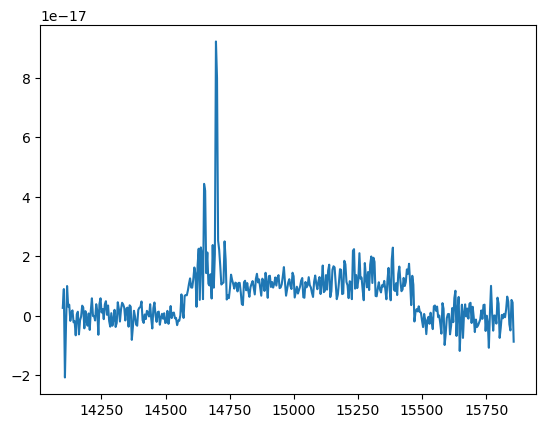

In [63]:
spec = cube.get_spectrum(1074.3, 1032.3, 1)
spec.plot()

unknown|WARNING| lines passed as float
unknown|INFO| lines: ['[NII]6548', 'HeI6678', '[SII]6731', 'H3', '[NII]6584', '[SII]6717']
unknown|INFO| estimated velocities: [-802.5477707006369]


BIC:  -15737.903721710087


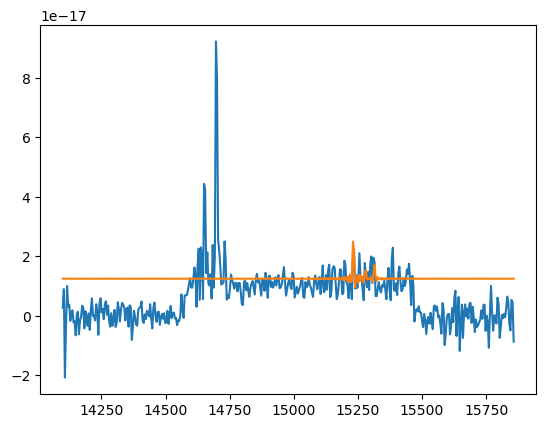

In [58]:
fit = spec.autofit() #single component fit (sinc)
spec.plot()
fit.get_spectrum().plot()
print('BIC: ', fit.BIC)

unknown|WARNING| lines passed as float
unknown|INFO| lines: ['[NII]6548', 'HeI6678', '[SII]6731', 'H3', '[NII]6584', '[SII]6717']
unknown|INFO| estimated velocities: [-802.5477707006369]


BIC:  -15737.903721710087


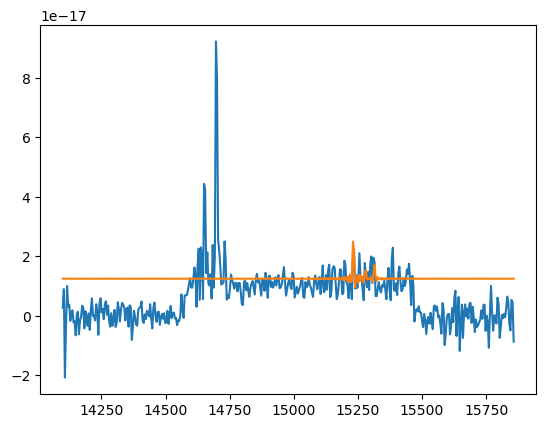

In [59]:
fit = spec.autofit(fmodel='sincgauss') #sincgauss
spec.plot()
fit.get_spectrum().plot()
print('BIC: ', fit.BIC)

unknown|WARNING| lines passed as float
unknown|INFO| lines: ['[NII]6548', 'HeI6678', '[SII]6731', 'H3', '[NII]6584', '[SII]6717']
unknown|INFO| estimated velocities: [-802.5477707006369, 709.1295116772822, -4.246284501061609]


BIC:  -15675.430334938348


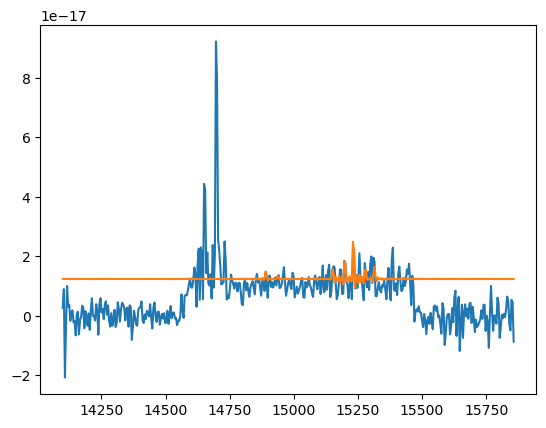

In [60]:
fit = spec.autofit(max_comps=3) #multiple component 
spec.plot()
fit.get_spectrum().plot()
print('BIC: ', fit.BIC)

In [61]:
cube.set_flambda(cube.compute_flambda())

unknown|WARNING| optics file could not be loaded, a 100% transmission is considered
unknown|INFO| mean flambda config: 2.4543305333447918e-17
unknown|INFO| standard_spectrum not set: no relative vector correction computed
unknown|INFO| standard_path not set: no relative vector correction computed
unknown|INFO| standard_image not set: no absolute vector correction computed
unknown|WARNING| optics file could not be loaded, a 100% transmission is considered
unknown|WARNING| internal data should be already calibrated in erg/cm2/s/A. Setting a new flambda will not change the data.


In [62]:
type(cube)


orcs.process.SpectralCube

unknown|WARNING| lines passed as float
unknown|INFO| lines: ['[NII]6548', 'HeI6678', '[SII]6731', 'H3', '[NII]6584', '[SII]6717']
unknown|INFO| estimated velocities: [-802.5477707006369, 709.1295116772822, -4.246284501061609, 1515.9235668789806, 1804.6709129511678]


BIC:  -15612.528818468887


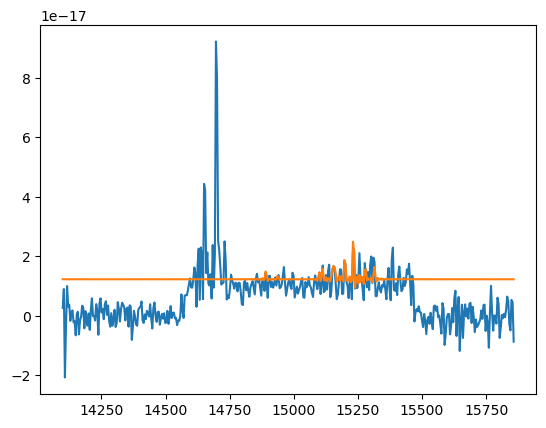

In [65]:
fit = spec.autofit(max_comps=5) #multiple component 
spec.plot()
fit.get_spectrum().plot()
print('BIC: ', fit.BIC)